In [1]:
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
from rasterio import open as rio_open
from rasterio.mask import mask

In [2]:

cwd_path = Path.cwd()   
repo_path = cwd_path.parent
data_path = repo_path/'data'
local_data_path = Path('C:/data')

In [3]:
# Create envelope around the network
ls_station_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsstations")
msls_station_path = local_data_path.joinpath("raw", "StedinData", "MiddenLaagspanningsstations")
ms_station_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsstations")

raw_paths = [ls_station_path,msls_station_path,ms_station_path]

for path in raw_paths:
    assert path.exists(), f"Path {path} does not exist"


In [4]:
# load road network, find bounding box, and clip electricity stations to the bounding box
road_network_path = data_path / 'static' / 'network' / 'try_study_area.shp'
road_network = gpd.read_file(road_network_path)
bounding_box = road_network.union_all().envelope    

In [5]:
# load the shapefiles and clip to the bounding box
ls_stations = gpd.read_file(ls_station_path/'Laagspanningsstations.shp')
ls_stations = ls_stations.to_crs(road_network.crs)  # Ensure CRS matches
ls_stations = ls_stations.clip(bounding_box)
msls_stations = gpd.read_file(msls_station_path/'MiddenLaagspanningsstations.shp')
msls_stations = msls_stations.to_crs(road_network.crs)
msls_stations = msls_stations.clip(bounding_box)
ms_stations = gpd.read_file(ms_station_path/'Middenspanningsstations.shp')
ms_stations = ms_stations.to_crs(road_network.crs)  # Ensure CRS matches
ms_stations = ms_stations.clip(bounding_box)

In [6]:
# save to repo data folder
ls_stations.to_file(data_path/'electricity'/'ls_stations_clipped.shp')
msls_stations.to_file(data_path/'electricity'/'msls_stations_clipped.shp')
ms_stations.to_file(data_path/'electricity'/'ms_stations_clipped.shp')

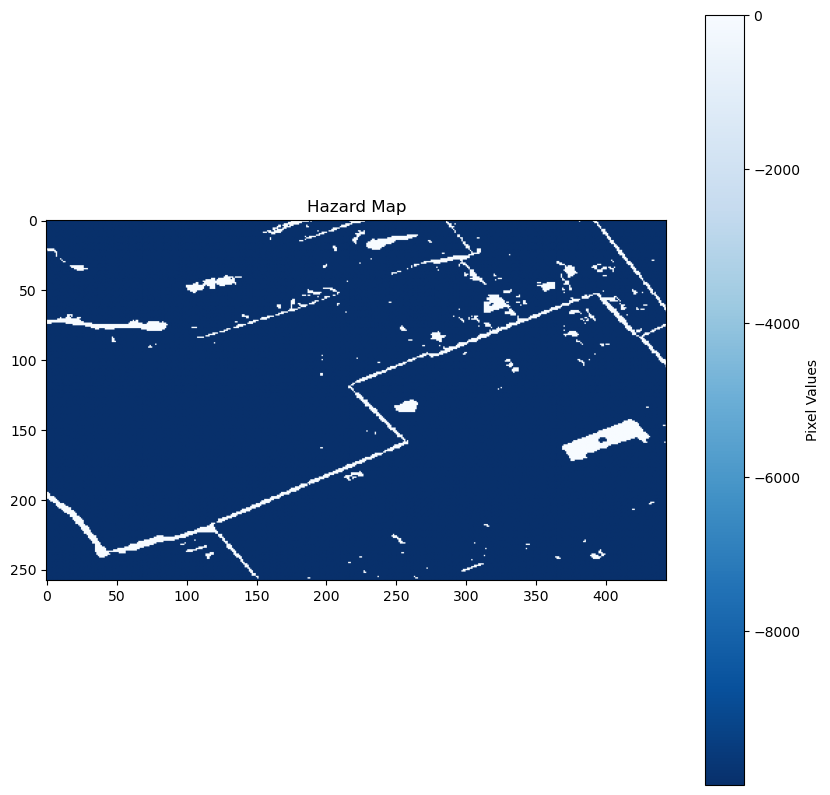

In [7]:
# clip hazard map
hazard_map_path = data_path / 'static/hazard/processed/delfland_ghg200m_wgs84_processed.tif'
assert hazard_map_path.exists(), f"Path {hazard_map_path} does not exist"


with rio_open(hazard_map_path) as src:
    hazard_map = src.read(1)
    hazard_transform = src.transform
    hazard_crs = src.crs
    
    # Reproject bounding_box to hazard_crs using GeoSeries
    bounding_box_gs = gpd.GeoSeries([bounding_box], crs=road_network.crs)
    bounding_box_haz_crs = bounding_box_gs.to_crs(hazard_crs).iloc[0]
    hazard_map_clipped, hazard_transform_clipped = mask(src, [bounding_box_haz_crs], crop=True)

# plot the hazard map
plt.figure(figsize=(10, 10))
plt.imshow(hazard_map_clipped[0], cmap='Blues_r')  # Change the colormap if desired
plt.colorbar(label='Pixel Values')  
plt.title('Hazard Map')
plt.show()


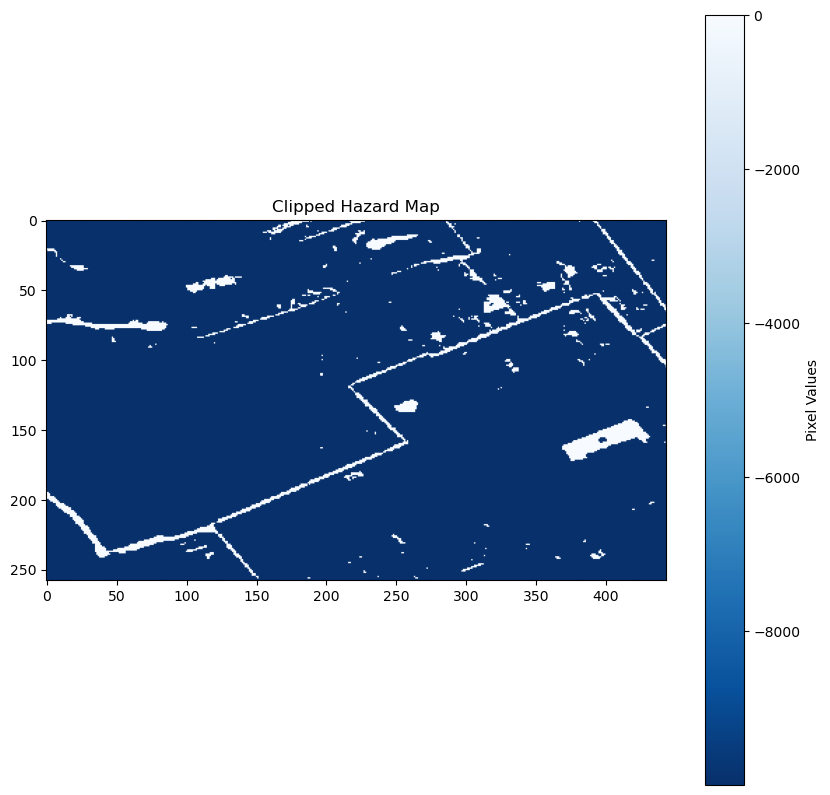

In [8]:
# save the clipped hazard map
clipped_hazard_map_path = data_path / 'static' / 'hazard' / 'processed' / 'clipped_hazard_map.tif'
with rio_open(clipped_hazard_map_path, 'w', driver='GTiff',
             height=hazard_map_clipped.shape[1], width=hazard_map_clipped.shape[2],
             count=1, dtype=hazard_map_clipped.dtype,
             crs=hazard_crs, transform=hazard_transform_clipped) as dst:
    dst.write(hazard_map_clipped[0], 1)

# load the clipped hazard map
clipped_hazard_map = rio_open(clipped_hazard_map_path)
# plot the clipped hazard map
plt.figure(figsize=(10, 10))
plt.imshow(clipped_hazard_map.read(1), cmap='Blues_r')  # Change the colormap if desired
plt.colorbar(label='Pixel Values')
plt.title('Clipped Hazard Map')
plt.show()